In [1]:
#Prior to executing the code, please unzip the compressed archive and copy all extracted files into the working directory of your Jupyter Notebook.
#Verify that both the code script and the corresponding Excel data file are available in the Jupyter environment.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import base64

In [3]:
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_package("pandas")
install_package("openpyxl")

import pandas as pd
import os

In [4]:
pip install pandas openpyxl numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import os

current_dir = os.getcwd()
file_path = os.path.join(current_dir, "000001_PingAn_Bank.xlsx")

print("File path ：", file_path)
print("File exists ：", os.path.exists(file_path))

data = pd.read_excel(
    file_path,
    header=1,
    engine='openpyxl'
)

print("\n Read successfully! First 5 rows of data:")
print(data.head())

File path ： /Volumes/唐然/西交利物浦大学/Y2S2/2470033/000001_PingAn_Bank.xlsx
File exists ： True

 Read successfully! First 5 rows of data:
   没有单位      没有单位.1    元/股  元/股.1  元/股.2  元/股.3         股             元  \
0     1  2021-04-26  23.87  24.23  22.90  22.94  87241767  2.037110e+09   
1     1  2021-04-27  22.95  23.19  22.86  22.94  47043140  1.083044e+09   
2     1  2021-04-28  23.29  23.45  22.78  23.35  59383793  1.375141e+09   
3     1  2021-04-29  23.34  23.71  23.11  23.59  61483688  1.439824e+09   
4     1  2021-04-30  23.35  23.49  23.01  23.29  56198132  1.308177e+09   

             千元          千元.1  ...  没有单位.4      没有单位.5  没有单位.6  股.1  元.1  \
0  4.451680e+08  4.451718e+08  ...       4  2020-12-31       1    0    0   
1  4.451680e+08  4.451718e+08  ...       4  2020-12-31       1    0    0   
2  4.531244e+08  4.531282e+08  ...       4  2020-12-31       1    0    0   
3  4.577817e+08  4.577856e+08  ...       4  2020-12-31       1    0    0   
4  4.519600e+08  4.519638e+08  ...    

In [6]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams["font.family"] = ["DejaVu Sans", "Arial", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False  # Fix negative sign display issue

Target stock code: 000001
Rows after filtering: 1163


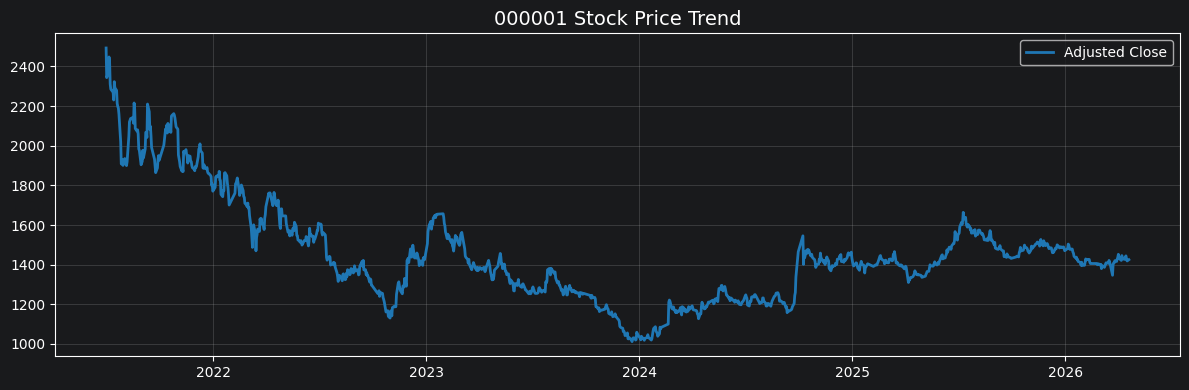

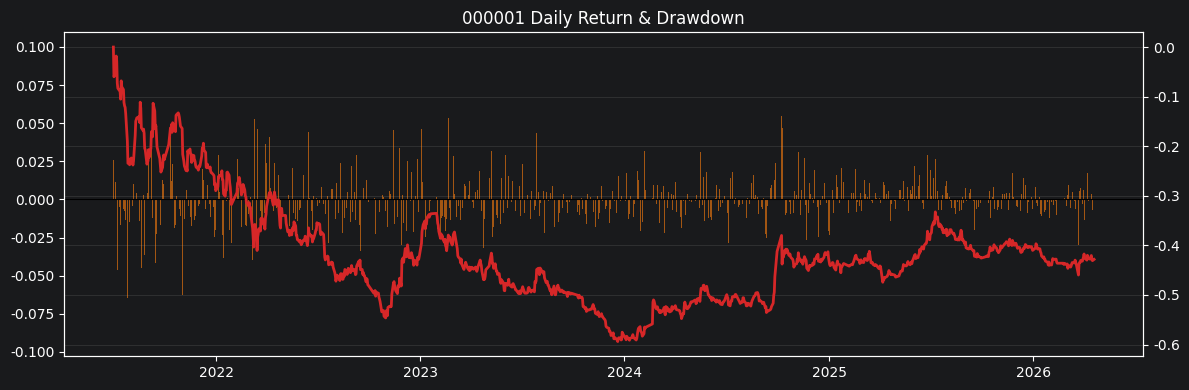

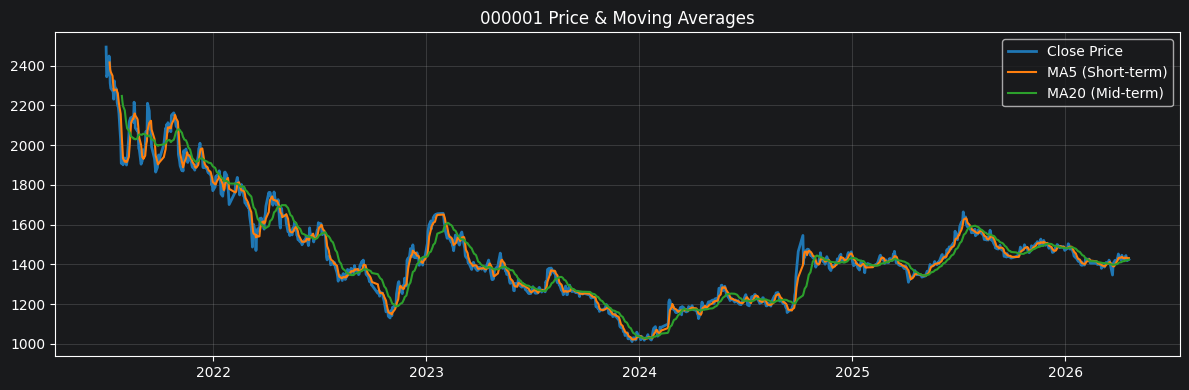

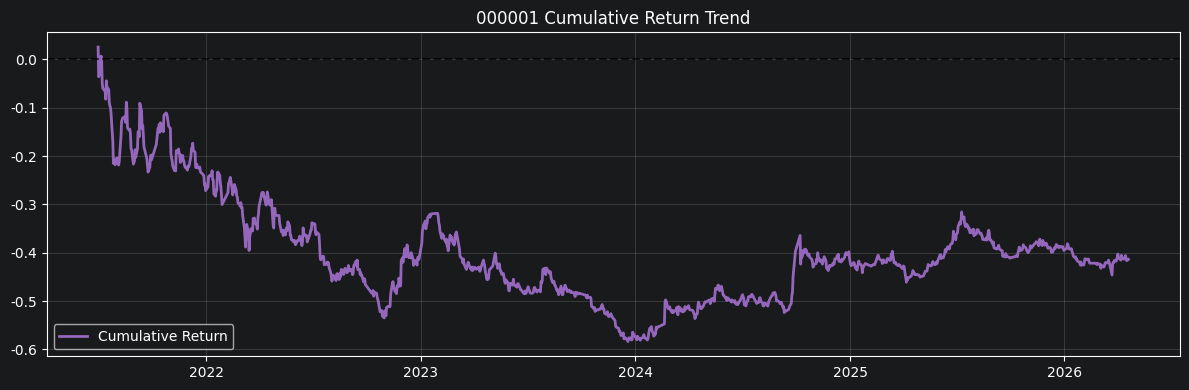


ACC102 PING AN BANK (000001) ANALYSIS REPORT
Stock Code:         000001
Analysis Period:    2021-07-01 to 2026-04-20
Trading Days:       1163

[ PRICE PERFORMANCE ]
Average Adjusted Close:    1452.69 CNY
Latest Adjusted Close:     1425.26 CNY
Highest Close in Period:   2492.79 CNY
Lowest Close in Period:    1012.06 CNY

[ RETURN PERFORMANCE ]
Average Daily Return:      -0.032%
Cumulative Total Return:   -41.358%
Annualized Return:         -8.149%

[ RISK INDICATORS ]
Annual Volatility:         26.206%
Maximum Drawdown:          -59.401%
Sharpe Ratio:              -0.43   ( >1 means good risk-adjusted return )

[ TRADING STATISTICS ]
Up Days:          517    (44.45%)
Down Days:        616    (52.97%)
Flat Days:        30    (2.58%)

ANALYSIS CONCLUSION:
1. The stock showed a cumulative return of -41.36% during the period, with annualized return of -8.15%.
2. Risk evaluation: Annual volatility is 26.21%, max drawdown reached -59.40%.
3. Sharpe ratio is -0.43, indicating the risk-adjuste

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
import base64
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
pd.options.mode.chained_assignment = None

def analyze_stock(stock_code, start_date, end_date):
    #Load data
    df = pd.read_excel("000001_PingAn_Bank.xlsx")

    #Date processing
    df["交易日期"] = pd.to_datetime(df["交易日期"].astype(str), errors="coerce")
    df = df.assign(证券代码=df["证券代码"].astype(str).str.strip())

    #Filter time & stock
    df = df[(df["交易日期"] >= start_date) & (df["交易日期"] <= end_date)]
    df = df[df["证券代码"] == str(stock_code).strip()].copy()

    print(f"Target stock code: {stock_code}")
    print(f"Rows after filtering: {len(df)}")

    if len(df) == 0:
        return "NO DATA", None, None, None, None

    #Sort & index
    df = df.sort_values("交易日期").set_index("交易日期")

    #Data cleaning
    df = df.dropna(subset=["考虑现金红利再投资的日个股回报率", "考虑现金红利再投资的收盘价的可比价格"])
    df = df[df["考虑现金红利再投资的收盘价的可比价格"] > 0]

    #Core variables
    price_col = "考虑现金红利再投资的收盘价的可比价格"
    df = df.assign(daily_return=df["考虑现金红利再投资的日个股回报率"])

    df = df.assign(MA5=df[price_col].rolling(5).mean())        #5-day moving average (MA5)
    df = df.assign(MA20=df[price_col].rolling(20).mean())      #20-day moving average (MA20)
    df = df.assign(cum_return=(1 + df["daily_return"]).cumprod() - 1) #cumulative returns
    df = df.assign(cummax=df[price_col].cummax())
    df = df.assign(drawdown=df[price_col] / df["cummax"] - 1)

    #Basic indicators
    avg_close = df[price_col].mean()
    latest_close = df[price_col].iloc[-1]
    avg_daily_return = df["daily_return"].mean()
    annual_return = avg_daily_return * 252
    cum_return_total = df["cum_return"].iloc[-1]
    annual_vol = df["daily_return"].std() * np.sqrt(252)
    max_drawdown = df["drawdown"].min()

    risk_free = 0.03
    sharpe_ratio = (annual_return - risk_free) / annual_vol  #Sharpe Ratio
    up_days = len(df[df["daily_return"] > 0])                 #Number of positive return days
    down_days = len(df[df["daily_return"] < 0])              #Number of negative return days
    flat_days = len(df[df["daily_return"] == 0])              #Number of zero return days

    #CHART 1: Price Trend
    plt.figure(figsize=(12, 4))
    plt.plot(df[price_col], color="#1f77b4", linewidth=2, label="Adjusted Close")
    plt.title(f"{stock_code} Stock Price Trend", fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    #CHART 2: Return & Drawdown
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.bar(df.index, df["daily_return"], color="#ff7f0e", alpha=0.6, label="Daily Return")
    ax1.axhline(0, lw=0.8, c="black")
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["drawdown"], color="#d62728", linewidth=2, label="Drawdown")
    plt.title(f"{stock_code} Daily Return & Drawdown")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    #CHART 3: Price + Moving Averages (NEW)
    plt.figure(figsize=(12, 4))
    plt.plot(df[price_col], linewidth=2, label="Close Price", color="#1f77b4")
    plt.plot(df["MA5"], linewidth=1.5, label="MA5 (Short-term)", color="#ff7f0e")
    plt.plot(df["MA20"], linewidth=1.5, label="MA20 (Mid-term)", color="#2ca02c")
    plt.title(f"{stock_code} Price & Moving Averages")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    #CHART 4: Cumulative Return Curve
    plt.figure(figsize=(12, 4))
    plt.plot(df["cum_return"], color="#9467bd", linewidth=2, label="Cumulative Return")
    plt.axhline(0, color="black", linestyle="--", alpha=0.7)
    plt.title(f"{stock_code} Cumulative Return Trend")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # DETAILED ENGLISH REPORT
    report = f"""
                          ACC102 PING AN BANK (000001) ANALYSIS REPORT
Stock Code:         {stock_code}
Analysis Period:    {start_date} to {end_date}
Trading Days:       {len(df)}

[ PRICE PERFORMANCE ]
Average Adjusted Close:    {avg_close:.2f} CNY
Latest Adjusted Close:     {latest_close:.2f} CNY
Highest Close in Period:   {df[price_col].max():.2f} CNY
Lowest Close in Period:    {df[price_col].min():.2f} CNY

[ RETURN PERFORMANCE ]
Average Daily Return:      {avg_daily_return:.3%}
Cumulative Total Return:   {cum_return_total:.3%}
Annualized Return:         {annual_return:.3%}

[ RISK INDICATORS ]
Annual Volatility:         {annual_vol:.3%}
Maximum Drawdown:          {max_drawdown:.3%}
Sharpe Ratio:              {sharpe_ratio:.2f}   ( >1 means good risk-adjusted return )

[ TRADING STATISTICS ]
Up Days:          {up_days}    ({up_days/len(df)*100:.2f}%)
Down Days:        {down_days}    ({down_days/len(df)*100:.2f}%)
Flat Days:        {flat_days}    ({flat_days/len(df)*100:.2f}%)

ANALYSIS CONCLUSION:
1. The stock showed a cumulative return of {cum_return_total:.2%} during the period, with annualized return of {annual_return:.2%}.
2. Risk evaluation: Annual volatility is {annual_vol:.2%}, max drawdown reached {max_drawdown:.2%}.
3. Sharpe ratio is {sharpe_ratio:.2f}, indicating the risk-adjusted performance is {'above average' if sharpe_ratio>1 else 'average'}.
4. Trading activity: {up_days/len(df)*100:.1f}% of trading days were positive.
5. Technical trend: The 5-day MA and 20-day MA reflect the short-term and mid-term price movement clearly.
"""
    return report.strip()

#RUN THE FULL ANALYSIS
if __name__ == "__main__":
    final_report = analyze_stock(
        stock_code="000001",
        start_date="2021-07-01",
        end_date="2026-04-20"
    )
    print("\n" + final_report)